# Imports/Installs

In [ ]:
#necessary imports here
!pip install geopandas
!pip install tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


# Big Picture
Download csv from this link and add to /content/ directory: https://data.virginia.gov/dataset/vdh-virginia-single-race-population-estimates

In [ ]:
np.random.seed(42)

#load data function
def load_va_population_data():
    df = pd.read_csv('/content/va_population.csv')  #update path if needed
    df = df.dropna()

    dataset_size_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    print(f"Dataset size: {dataset_size_mb:.2f} MB\n")

    #num of features and records
    entries_count = df.shape[0]
    print(f"Number of entries: {entries_count}\n")
    features_count = df.shape[1]
    print(f"Number of features: {features_count}\n")

    categorical_columns = df.select_dtypes(include=['object']).columns
    if len(categorical_columns) > 0:
        print(f"Categorical columns:\n{list(categorical_columns)}\n")
    else:
        print("No categorical columns.\n")

    #missing values
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    if len(missing_values) > 0:
        print(f"Missing values in these columns:\n{missing_values}\n")
    else:
        print("No missing values.\n")

    #basic stats
    stats = df.describe(include='all')
    print("Basic statistics:")
    print(stats)

    return df

#call load function
va_data = load_va_population_data()
va_data.head()


Dataset size: 866.62 MB

Number of entries: 804384

Number of features: 20

Categorical columns:
['STATE_NAME', 'CENSUS_SOURCE', 'GEOGRAPHY_LEVEL', 'LOCALITY', 'DISTRICT_NAME', 'REGION_NAME', 'ETHNICITY', 'RACE', 'TIERED_RACE_ETHNICITY', 'SEX', 'AGE_GROUP', 'AGE_VALUE', 'Create_Date', 'Modified_Date', 'Status']

No missing values.

Basic statistics:
                   ID STATE_NAME  ESTIMATE_YEAR           CENSUS_SOURCE  \
count   804384.000000     804384  804384.000000                  804384   
unique            NaN          1            NaN                       2   
top               NaN   Virginia            NaN  cc-est2020-alldata6-51   
freq              NaN     804384            NaN                  574560   
mean    417672.500000        NaN    2016.500000                     NaN   
std     240505.540972        NaN       4.031131                     NaN   
min       2065.000000        NaN    2010.000000                     NaN   
25%     209352.750000        NaN    2013.000000 

,ID,STATE_NAME,ESTIMATE_YEAR,CENSUS_SOURCE,GEOGRAPHY_LEVEL,FIPS_CODE,LOCALITY,DISTRICT_NAME,REGION_NAME,ETHNICITY,RACE,TIERED_RACE_ETHNICITY,SEX,AGE_GROUP,AGE_VALUE,ESTIMATE,AGE_VALUE_SORT,Create_Date,Modified_Date,Status
529,2133,Virginia,2010,cc-est2020-alldata6-51,County and/or Statistical Equivalent,51001.0,Accomack County,Eastern Shore,Eastern,Hispanic,Native Hawaiian and Other Pacific Islander alone,Latino,Female,5-years,75-79 years,0,115,2024-09-09 11:27:41.623,2024-09-20 16:51:03.327,Processed
530,2134,Virginia,2010,cc-est2020-alldata6-51,County and/or Statistical Equivalent,51001.0,Accomack County,Eastern Shore,Eastern,Hispanic,Black or African American alone,Latino,Female,5-years,20-24 years,7,104,2024-09-09 11:27:41.623,2024-09-20 16:51:03.327,Processed
531,2135,Virginia,2010,cc-est2020-alldata6-51,County and/or Statistical Equivalent,51001.0,Accomack County,Eastern Shore,Eastern,Hispanic,White alone,Latino,Female,5-years,55-59 years,17,111,2024-09-09 11:27:41.623,2024-09-20 16:51:03.327,Processed
532,2136,Virginia,2010,cc-est2020-alldata6-51,County and/or Statistical Equivalent,51001.0,Accomack County,Eastern Shore,Eastern,Hispanic,Two or More Races,Latino,Female,5-years,40-44 years,0,108,2024-09-09 11:27:41.623,2024-09-20 16:51:03.343,Processed
533,2137,Virginia,2010,cc-est2020-alldata6-51,County and/or Statistical Equivalent,51001.0,Accomack County,Eastern Shore,Eastern,Hispanic,White alone,Latino,Female,5-years,0-4 years,191,100,2024-09-09 11:27:41.623,2024-09-20 16:51:03.343,Processed


# DATA DISCOVERY, CLEANING, AND SCALING

Correlation with ESTIMATE:
ESTIMATE          1.000000
FIPS_CODE         0.008499
ESTIMATE_YEAR     0.005112
ID                0.005109
AGE_VALUE_SORT   -0.047287
Name: ESTIMATE, dtype: float64 



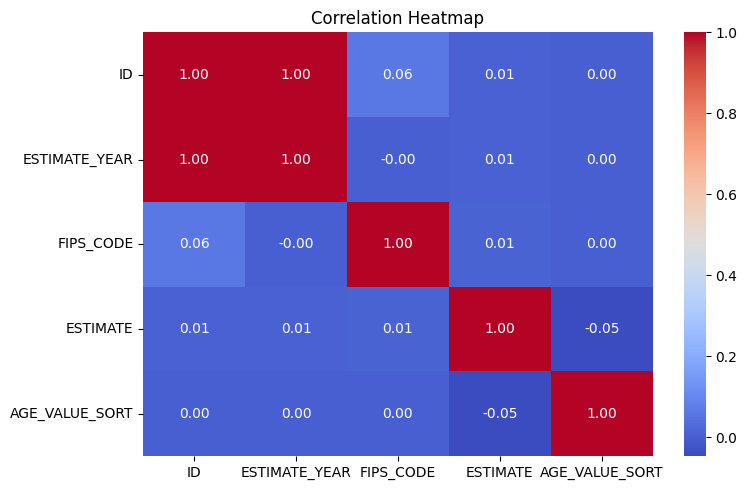

X_train shape: (643507, 14)
y_train shape: (643507,)
X_test shape: (160877, 14)
y_test shape: (160877,)
X_train transformed shape: (643507, 214)
X_test transformed shape: (160877, 214)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#corr matrix
corr_matrix = va_data.corr(numeric_only=True)
if "ESTIMATE" in corr_matrix.columns:
    print("Correlation with ESTIMATE:")
    print(corr_matrix["ESTIMATE"].sort_values(ascending=False), "\n")
else:
    print("ESTIMATE not found in correlation matrix.\n")

#matrix for better visuals
numeric_df = va_data.select_dtypes(include=['number']).dropna(axis=1, how='all')
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]
if numeric_df.shape[1] > 1:
    plt.figure(figsize=(8, 5))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric features for heatmap.")

#drop irrelevant columns, don't need id column or source, etc.
columns_to_drop = ["ID", "Create_Date", "Modified_Date", "Status", "CENSUS_SOURCE"]
df_clean = va_data.drop(columns=[col for col in columns_to_drop if col in va_data.columns])

#we have enough data that rows with null values can be dropped
df_clean = df_clean[df_clean["ESTIMATE"].notnull()]

#split features and and target
X = df_clean.drop("ESTIMATE", axis=1)
y = df_clean["ESTIMATE"]

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

#column types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

#separate numeric and cat pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

#combined pipeline
full_pipeline = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)
print("X_train transformed shape:", X_train_prepared.shape)
print("X_test transformed shape:", X_test_prepared.shape)

# Baseline: Linear Regression

Cross-Validated RMSE scores: [595.95934524 582.65636142 598.26607176 572.97581041 585.4789126 ]
Average RMSE: 587.07
Standard Deviation: 9.22


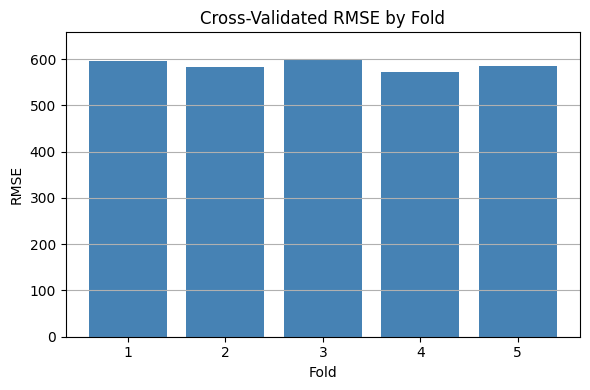

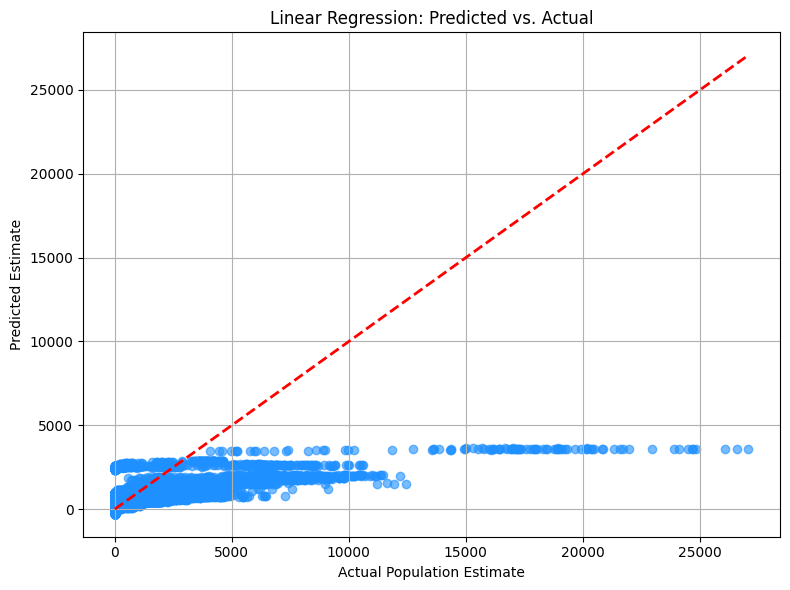

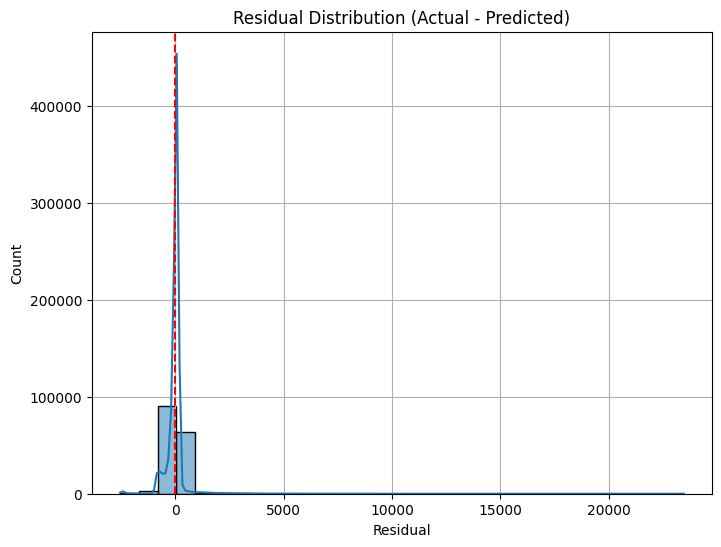

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_squared_error

#use full pipeline and features
lin_reg = LinearRegression()

#score with rmse
neg_rmse_scores = cross_val_score(
    lin_reg,
    X_train_prepared,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
    #5-fold cross-validation
)
rmse_scores = -neg_rmse_scores

#print metrics
print("Cross-Validated RMSE scores:", rmse_scores)
print(f"Average RMSE: {rmse_scores.mean():.2f}")
print(f"Standard Deviation: {rmse_scores.std():.2f}")

#visualize metrics with plt:
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(rmse_scores) + 1), rmse_scores, color='steelblue')
plt.title("Cross-Validated RMSE by Fold")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks(range(1, len(rmse_scores) + 1))
plt.ylim(0, max(rmse_scores) * 1.1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
print()

#train and predict on testing set
lin_reg.fit(X_train_prepared, y_train)
y_pred = lin_reg.predict(X_test_prepared)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Population Estimate")
plt.ylabel("Predicted Estimate")
plt.title("Linear Regression: Predicted vs. Actual")
plt.grid(True)
plt.tight_layout()
plt.show()
print()

#residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.axvline(0, color='red', linestyle='--')
plt.grid(True)
plt.show()

# Random Forest Regressor

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import numpy as np

X = df_clean.drop(columns='ESTIMATE')
y = df_clean['ESTIMATE']

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

#select numeric features with sufficient correlation
correlations = df_clean[numeric_features + ['ESTIMATE']].corr()['ESTIMATE'].drop('ESTIMATE')
selected_numeric = correlations[abs(correlations) > 0.05].index.tolist()

#select categorical features with non-zero mutual information
#ordinal encode categoricals temporarily for MI scoring
X_cats_encoded = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(
    X[categorical_features].fillna("missing")
)

mi_scores = mutual_info_regression(X_cats_encoded, y)
selected_categorical = [f for f, score in zip(categorical_features, mi_scores) if score > 0.001]

print("Selected numeric features:", selected_numeric)
print("Selected categorical features:", selected_categorical)

#process
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])
full_pipeline = ColumnTransformer([
    ("num", numeric_pipeline, selected_numeric),
    ("cat", categorical_pipeline, selected_categorical)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)
rf = RandomForestRegressor(n_estimators=25, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train_prepared, y_train)

#get top 4 important features
feature_names = full_pipeline.get_feature_names_out()
importances = rf.feature_importances_
nonzero_indices = np.where(importances > 0)[0]
sorted_indices = nonzero_indices[np.argsort(importances[nonzero_indices])[::-1]]
top_indices = sorted_indices[:4]
top_features = feature_names[top_indices]

print("Top features based on Random Forest importance:")
for i, name in enumerate(top_features, 1):
    print(f"{i}. {name}")


Selected numeric features: []
Selected categorical features: ['LOCALITY', 'DISTRICT_NAME', 'REGION_NAME', 'ETHNICITY', 'RACE', 'TIERED_RACE_ETHNICITY', 'AGE_GROUP', 'AGE_VALUE']
Top features based on Random Forest importance:
1. cat__LOCALITY_Fairfax County
2. cat__TIERED_RACE_ETHNICITY_White
3. cat__DISTRICT_NAME_Virginia Beach
4. cat__LOCALITY_Chesterfield County


# More RandomForest Regression

Random Forest Regressor
RMSE: 266.31
R² Score: 0.8663


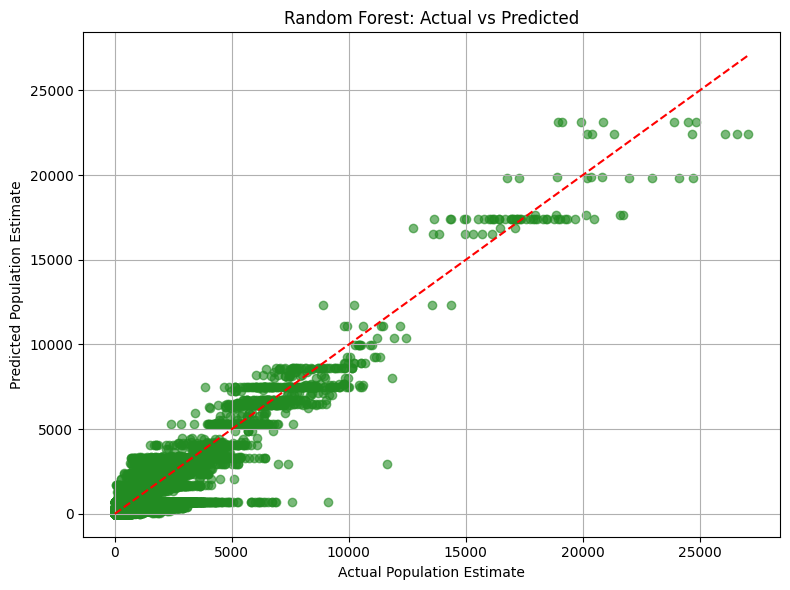

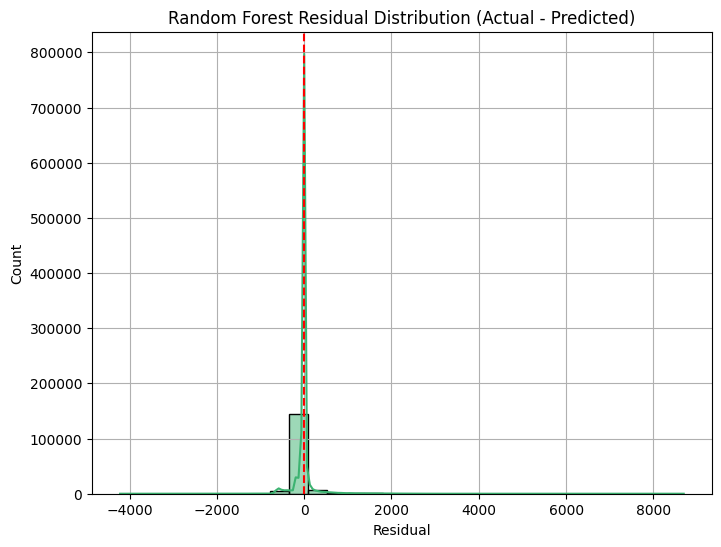

,Actual,Predicted,Residual,Abs_Error
180455,11638,2943.182602,8694.817398,8694.817398
206459,9111,713.316746,8397.683254,8397.683254
53556,7557,713.316746,6843.683254,6843.683254
472690,6889,713.316746,6175.683254,6175.683254
532210,6861,713.316746,6147.683254,6147.683254
770139,6712,713.316746,5998.683254,5998.683254
265885,6707,713.316746,5993.683254,5993.683254
294132,6530,713.316746,5816.683254,5816.683254
591733,6422,713.316746,5708.683254,5708.683254
60576,6311,713.316746,5597.683254,5597.683254


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

y_pred_rf = rf.predict(X_test_prepared)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Population Estimate")
plt.ylabel("Predicted Population Estimate")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()
print()

residuals_rf = y_test - y_pred_rf
plt.figure(figsize=(8, 6))
sns.histplot(residuals_rf, bins=30, kde=True, color='mediumseagreen')
plt.title("Random Forest Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.axvline(0, color='red', linestyle='--')
plt.grid(True)
plt.show()
print()

rf_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf,
    "Residual": residuals_rf
})
rf_results["Abs_Error"] = rf_results["Residual"].abs()
rf_results = rf_results.sort_values(by="Abs_Error", ascending=False)



# LSTM (time series forecasting)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# clean data
pivot_df = df_clean.pivot_table(
    index="LOCALITY",
    columns="ESTIMATE_YEAR",
    values="ESTIMATE",
    aggfunc="sum"  #sum across demographic breakdowns per county/year
)

pivot_df_clean = pivot_df.dropna()
data = pivot_df_clean.values

timesteps = data.shape[1] - 1
X = data[:, :timesteps]
y = data[:, timesteps]

#normalize X and y separately
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

X_lstm = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

#train/test split
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_scaled, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (106, 13, 1)
y_train shape: (106, 1)


ERROR: Could not find a version that satisfies the requirement tensorflow==2.11.0 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.0.post1, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0)
ERROR: No matching distribution found for tensorflow==2.11.0


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 275ms/step - loss: 0.0092 - val_loss: 0.0052
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0034 - val_loss: 0.0027
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - val_loss: 4.5554e-04
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.7084e-04 - val_loss: 1.2899e-04
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.9562e-04 - val_loss: 3.0978e-04
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.1256e-04 - val_loss: 3.2263e-05
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.4206e-04 - val_loss: 3.4775e-05
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.6029e-05 - val_loss: 4.6726e-05
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9844e-05 - val_loss: 1.8367e-05
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0866e-04 - val_loss: 2.7797e-05
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016 - val_loss: 4.6011e-04
Epoch 12/

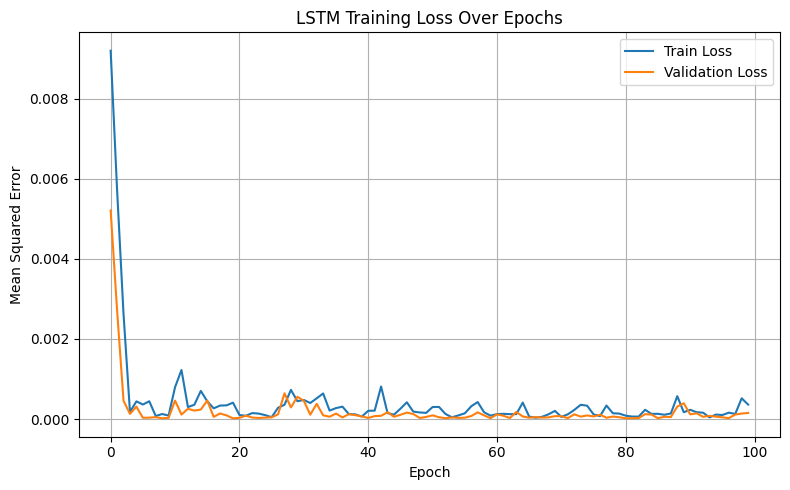

In [ ]:
!pip install tensorflow==2.11.0
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#define LSTM model
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  #output layer for population prediction
])

model.compile(optimizer='adam', loss='mse')

#train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    verbose=1
)

#plotting training history
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Mean Absolute Error (MAE): 12976.76
Root Mean Squared Error (RMSE): 14049.22


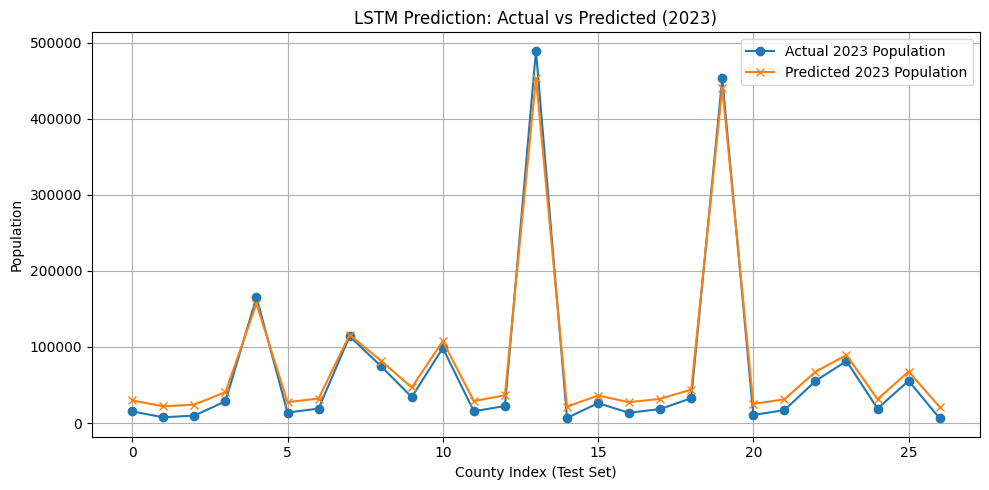

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

#predicting on test set
y_pred_scaled = model.predict(X_test)

#inverse transform both y_pred and y_test
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test)

#calculate metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


#visualize
plt.figure(figsize=(10, 5))
plt.plot(y_true, label='Actual 2023 Population', marker='o')
plt.plot(y_pred, label='Predicted 2023 Population', marker='x')
plt.title("LSTM Prediction: Actual vs Predicted (2023)")
plt.xlabel("County Index (Test Set)")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Root Mean Squared Error (RMSE): 14049.22


# Graphs for Scene 1

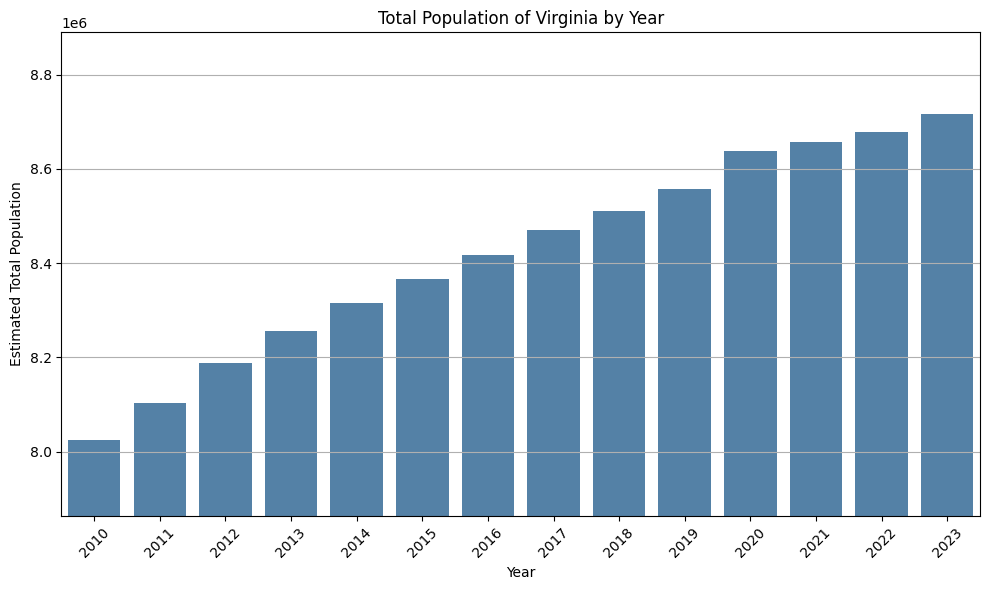

In [ ]:
va_total_by_year = df_clean.groupby("ESTIMATE_YEAR")["ESTIMATE"].sum().reset_index()

ymin = va_total_by_year["ESTIMATE"].min() * 0.98
ymax = va_total_by_year["ESTIMATE"].max() * 1.02

plt.figure(figsize=(10, 6))
sns.barplot(data=va_total_by_year, x="ESTIMATE_YEAR", y="ESTIMATE", color="steelblue")
plt.title("Total Population of Virginia by Year")
plt.xlabel("Year")
plt.ylabel("Estimated Total Population")
plt.xticks(rotation=45)
plt.ylim(ymin, ymax)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


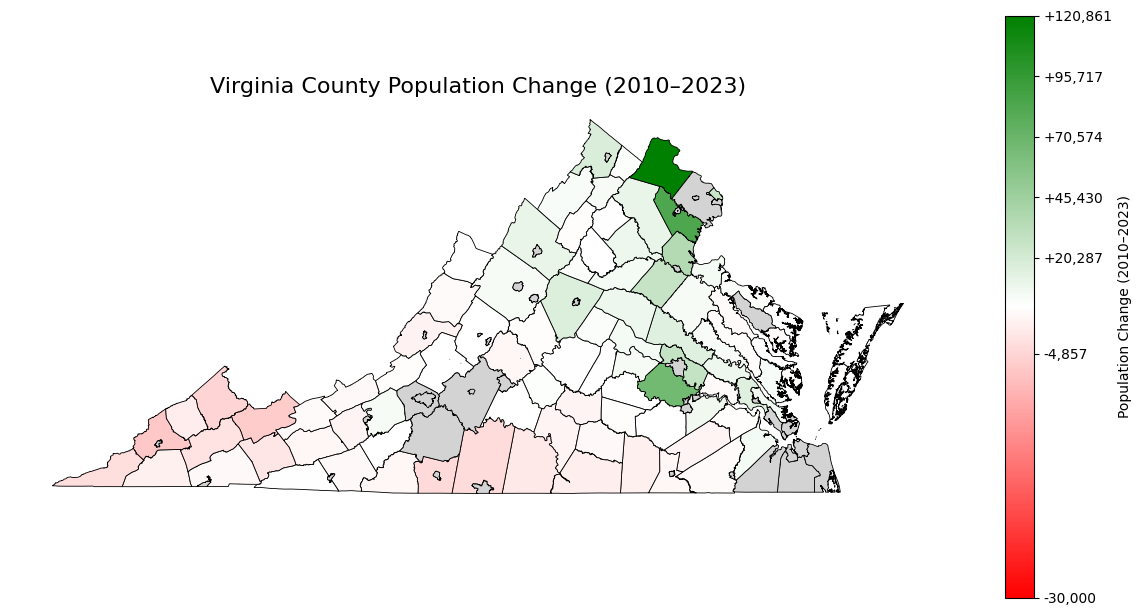

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

va_map = gpd.read_file("va_counties.geojson")
va_map["NAME"] = va_map["NAME"].str.strip() + " County"

df_2010 = df_clean[df_clean["ESTIMATE_YEAR"] == 2010]
df_2023 = df_clean[df_clean["ESTIMATE_YEAR"] == 2023]
pop_2010 = df_2010.groupby("LOCALITY")["ESTIMATE"].sum()
pop_2023 = df_2023.groupby("LOCALITY")["ESTIMATE"].sum()

pop_change = (pop_2023 - pop_2010).reset_index()
pop_change.columns = ["LOCALITY", "POP_CHANGE"]

va_map_merged = va_map.merge(pop_change, left_on="NAME", right_on="LOCALITY", how="left")

#soft clip
vmin = -30000
vmax = va_map_merged["POP_CHANGE"].max()
vcenter = 0

norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["red", "white", "green"])

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
va_map_merged.plot(
    column="POP_CHANGE",
    cmap=cmap,
    norm=norm,
    linewidth=0.6,
    edgecolor="black",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label("Population Change (2010–2023)")
tick_values = np.linspace(vmin, vmax, 7, dtype=int)
cbar.set_ticks(tick_values)
cbar.ax.set_yticklabels([f"{v:+,}" for v in tick_values])

ax.set_title("Virginia County Population Change (2010–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


# Scene 2 graphs

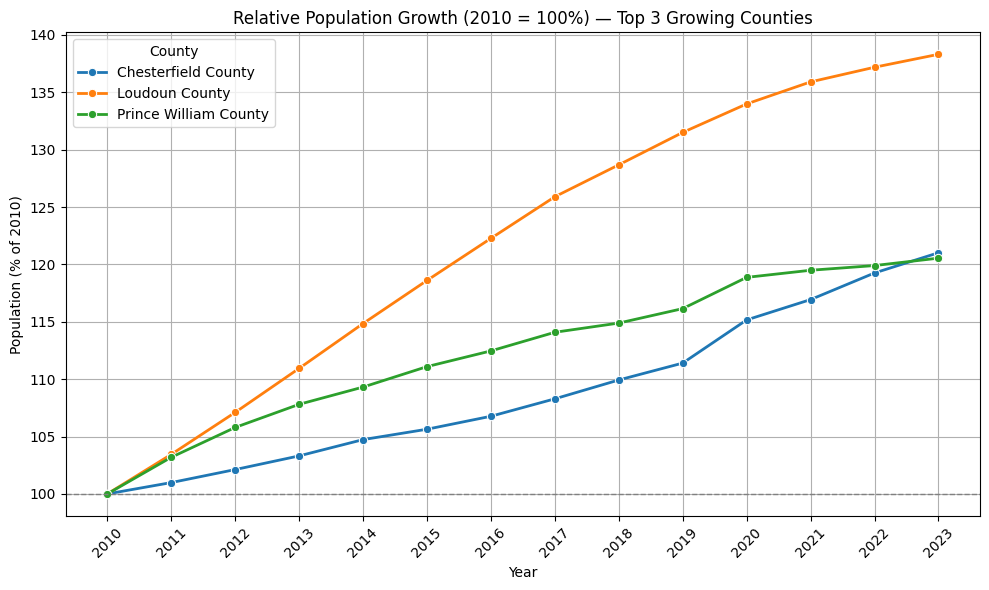

In [ ]:
df_2010 = df_clean[df_clean["ESTIMATE_YEAR"] == 2010]
df_2023 = df_clean[df_clean["ESTIMATE_YEAR"] == 2023]

pop_2010 = df_2010.groupby("LOCALITY")["ESTIMATE"].sum()
pop_2023 = df_2023.groupby("LOCALITY")["ESTIMATE"].sum()

pop_change = (pop_2023 - pop_2010).sort_values(ascending=False)
top_3_growers = pop_change.head(3).index.tolist()

top_df = df_clean[df_clean["LOCALITY"].isin(top_3_growers)]
yearly_counts = top_df.groupby(["LOCALITY", "ESTIMATE_YEAR"])["ESTIMATE"].sum().reset_index()

for county in top_3_growers:
    base_pop = pop_2010[county]
    yearly_counts.loc[yearly_counts["LOCALITY"] == county, "RELATIVE_POP"] = \
        yearly_counts[yearly_counts["LOCALITY"] == county]["ESTIMATE"] / base_pop * 100

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_counts, x="ESTIMATE_YEAR", y="RELATIVE_POP", hue="LOCALITY", marker="o", linewidth=2)
plt.title("Relative Population Growth (2010 = 100%) — Top 3 Growing Counties")
plt.xlabel("Year")
plt.ylabel("Population (% of 2010)")
plt.axhline(100, color='gray', linestyle='--', linewidth=1)
plt.xticks(sorted(yearly_counts["ESTIMATE_YEAR"].unique()), rotation=45)
plt.legend(title="County")
plt.grid(True)
plt.tight_layout()
plt.show()


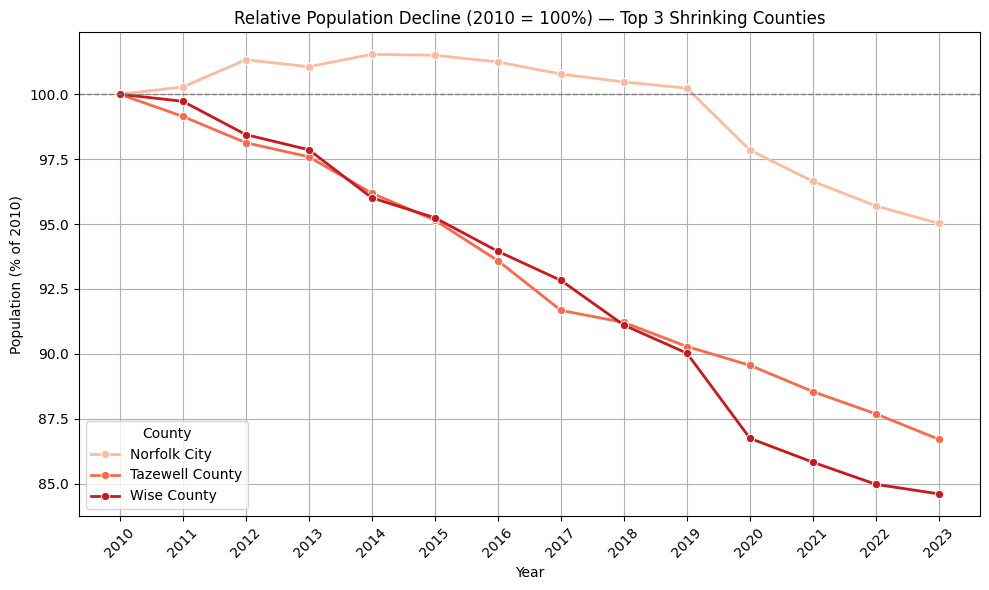

In [ ]:
pop_change = (pop_2023 - pop_2010).sort_values()
top_3_decliners = pop_change.head(3).index.tolist()

decline_df = df_clean[df_clean["LOCALITY"].isin(top_3_decliners)]
yearly_decline = decline_df.groupby(["LOCALITY", "ESTIMATE_YEAR"])["ESTIMATE"].sum().reset_index()

for county in top_3_decliners:
    base_pop = pop_2010[county]
    yearly_decline.loc[yearly_decline["LOCALITY"] == county, "RELATIVE_POP"] = \
        yearly_decline[yearly_decline["LOCALITY"] == county]["ESTIMATE"] / base_pop * 100

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_decline, x="ESTIMATE_YEAR", y="RELATIVE_POP", hue="LOCALITY", marker="o", linewidth=2, palette="Reds")
plt.title("Relative Population Decline (2010 = 100%) — Top 3 Shrinking Counties")
plt.xlabel("Year")
plt.ylabel("Population (% of 2010)")
plt.axhline(100, color='gray', linestyle='--', linewidth=1)
plt.xticks(sorted(yearly_decline["ESTIMATE_YEAR"].unique()), rotation=45)
plt.legend(title="County")
plt.grid(True)
plt.tight_layout()
plt.show()
